In [11]:
# ============================================================
# Cellule 1 — Imports (LR lag12 + MLForecast)
# ============================================================
import numpy as np
import pandas as pd
from dateutil.relativedelta import relativedelta

from utils import load_wide_from_feast

from mlforecast.utils import PredictionIntervals
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error

from utils import run_pseudo_oos_ar_p_no_bagging

In [12]:
# ============================================================
# Cellule 2 — Charger uniquement UNRATE (Feast) + ts_ar propre
# ============================================================
series_ids = ["UNRATE"]
START = "1960-01-01"
END   = "2025-08-01"

df = load_wide_from_feast(
    "stationary_value:value",
    series_ids,
    start=START,
    end=END
)

ts_ar = (
    df.reset_index()
      .rename(columns={"date": "ds", "UNRATE": "y"})
)

ts_ar["unique_id"] = "UNRATE"
ts_ar["ds"] = pd.to_datetime(ts_ar["ds"], errors="coerce")

# ✅ Fix timezone (si UTC)
if getattr(ts_ar["ds"].dt, "tz", None) is not None:
    ts_ar["ds"] = ts_ar["ds"].dt.tz_convert(None)

# ✅ Normaliser MS
ts_ar["ds"] = ts_ar["ds"].dt.to_period("M").dt.to_timestamp(how="start").dt.normalize()

ts_ar = (
    ts_ar[["unique_id", "ds", "y"]]
    .dropna(subset=["ds", "y"])
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

print("ts_ar shape:", ts_ar.shape)
print("Range:", ts_ar["ds"].min().date(), "→", ts_ar["ds"].max().date())
ts_ar.head()

Using date as the event timestamp. To specify a column explicitly, please name it event_timestamp.
ts_ar shape: (788, 3)
Range: 1960-01-01 → 2025-08-01


series_id,unique_id,ds,y
0,UNRATE,1960-01-01,-0.8
1,UNRATE,1960-02-01,-1.1
2,UNRATE,1960-03-01,-0.2
3,UNRATE,1960-04-01,0.0
4,UNRATE,1960-05-01,0.0


In [13]:
def ts_to_y(ts_ar: pd.DataFrame, uid="UNRATE") -> pd.Series:
    # filtre la série
    df = ts_ar.loc[ts_ar["unique_id"].eq(uid), ["ds", "y"]].copy()
    df["ds"] = pd.to_datetime(df["ds"])

    # force début de mois (MS) et trie
    df["ds"] = df["ds"].dt.to_period("M").dt.to_timestamp(how="start")
    df = df.sort_values("ds")

    # Series avec index DatetimeIndex
    y = df.set_index("ds")["y"].astype(float)

    # (optionnel) s'assurer que la fréquence est mensuelle MS
    y = y.asfreq("MS")
    return y

y = ts_to_y(ts_ar, uid="UNRATE")
print(y.head())

ds
1960-01-01   -0.8
1960-02-01   -1.1
1960-03-01   -0.2
1960-04-01    0.0
1960-05-01    0.0
Freq: MS, Name: y, dtype: float64


# AR12

In [14]:
# -----------------------------
# 2) Call AR(p) pseudo-OOS
# -----------------------------
df_oos_ar_p, meta_ar_p = run_pseudo_oos_ar_p_no_bagging(
    y,
    h=12,
    min_train_n=36,
    trend="c",
    p_grid=range(1, 13),
    cv_update_every_months=36,
    cv_anchor=pd.Timestamp("1983-01-01"),
    use_conformal=True,
    alpha=0.05,
    step_size=12,
    pi_windows=24,     # you can set 3 for faster/less stable, 24 for smoother
    verbose_cv=True,
)

[CV] 1983-01-01 → p* = 5
[CV] 1986-01-01 → p* = 4
[CV] 1989-01-01 → p* = 4
[CV] 1992-01-01 → p* = 4
[CV] 1995-01-01 → p* = 4
[CV] 1998-01-01 → p* = 4
[CV] 2001-01-01 → p* = 4
[CV] 2004-01-01 → p* = 4
[CV] 2007-01-01 → p* = 4
[CV] 2010-01-01 → p* = 4
[CV] 2013-01-01 → p* = 4
[CV] 2016-01-01 → p* = 4
[CV] 2019-01-01 → p* = 4
[CV] 2022-01-01 → p* = 4


# Transform Backtesting

In [15]:

# ============================================================
# 0) Convertir df_oos_ar_p (index=date_fore) -> format "rows"
# ============================================================
df_oos_ar_cv = (
    df_oos_ar_p.reset_index()
    .rename(columns={"date": "ds"})  # si ton index s'appelle "date" après reset
)

# Cas fréquent: après reset_index(), la colonne s'appelle "index"
if "ds" not in df_oos_ar_cv.columns:
    if "index" in df_oos_ar_cv.columns:
        df_oos_ar_cv = df_oos_ar_cv.rename(columns={"index": "ds"})
    else:
        # fallback: première colonne
        df_oos_ar_cv = df_oos_ar_cv.rename(columns={df_oos_ar_cv.columns[0]: "ds"})

# Garder uniquement les colonnes voulues (et dans l’ordre)
keep_cols = ["ds", "y_hat", "y_true", "p_selected", "lo_95", "hi_95"]
df_oos_ar_cv = df_oos_ar_cv[[c for c in keep_cols if c in df_oos_ar_cv.columns]].copy()

# Assurer tri / types
df_oos_ar_cv["ds"] = pd.to_datetime(df_oos_ar_cv["ds"], errors="coerce")
if pd.api.types.is_datetime64tz_dtype(df_oos_ar_cv["ds"]):
    df_oos_ar_cv["ds"] = df_oos_ar_cv["ds"].dt.tz_convert(None)

df_oos_ar_cv = df_oos_ar_cv.dropna(subset=["ds"]).sort_values("ds").reset_index(drop=True)

# =========================
# 1) Filtre période (optionnel)
# =========================
EXP_START = pd.Timestamp("1990-01-01")
EXP_END   = pd.Timestamp("2025-08-01")

df_oos_ar_cv = df_oos_ar_cv[
    (df_oos_ar_cv["ds"] >= EXP_START) &
    (df_oos_ar_cv["ds"] <= EXP_END)
].reset_index(drop=True)

# =========================
# 2) Partitions (comme toi)
# =========================
bins = pd.to_datetime([
    "1990-01-01",
    "2000-01-01",
    "2009-01-01",
    "2020-01-01",
    "2025-09-01"
])

labels = ["1990-1999", "2000-2008", "2009-2019", "2020-end"]

df_oos_ar_cv["partition"] = pd.cut(
    df_oos_ar_cv["ds"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

df_oos_ar_cv = df_oos_ar_cv.dropna(subset=["partition"]).reset_index(drop=True)

print(df_oos_ar_cv.head())
print("n preds:", len(df_oos_ar_cv))
print(df_oos_ar_cv["partition"].value_counts().sort_index())

          ds     y_hat  y_true  p_selected     lo_95     hi_95  partition
0 1990-01-01  0.038995     0.0           4 -2.732254  2.810245  1990-1999
1 1990-02-01 -0.158664     0.1           4 -2.900530  2.583202  1990-1999
2 1990-03-01 -0.338061     0.2           4 -3.795356  3.119235  1990-1999
3 1990-04-01  0.079964     0.2           4 -3.662996  3.822923  1990-1999
4 1990-05-01 -0.004353     0.2           4 -4.069663  4.060957  1990-1999
n preds: 428
partition
1990-1999    120
2000-2008    108
2009-2019    132
2020-end      68
Name: count, dtype: int64


C:\Users\Mita\AppData\Local\Temp\ipykernel_19024\247404319.py:23: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df_oos_ar_cv["ds"]):


# Leaderbord

In [16]:

tmp = df_oos_ar_cv.copy()

# =========================
# 0) Harmoniser colonnes (ARp)
# =========================
if "unique_id" not in tmp.columns:
    tmp["unique_id"] = "UNRATE"

tmp["y"] = tmp["y_true"].astype(float)
tmp["ARp"] = tmp["y_hat"].astype(float)

tmp["ARp-lo-95"] = pd.to_numeric(tmp["lo_95"], errors="coerce")
tmp["ARp-hi-95"] = pd.to_numeric(tmp["hi_95"], errors="coerce")

models = ["ARp"]

# =========================
# 1) S'assurer que lower <= upper
# =========================
for m in models:
    lo = f"{m}-lo-95"
    hi = f"{m}-hi-95"
    arr = tmp[[lo, hi]].to_numpy(dtype=float)
    arr_sorted = np.sort(arr, axis=1)
    tmp[lo] = arr_sorted[:, 0]
    tmp[hi] = arr_sorted[:, 1]

# =========================
# 2) Wide -> Long + scoring
# =========================
rows_sc = []
for m in models:
    lo = f"{m}-lo-95"
    hi = f"{m}-hi-95"

    s = tmp[["unique_id", "ds", "y", "partition"]].copy()
    s["cutoff"] = pd.NaT
    s["model_label"] = m
    s["model_name"]  = m

    s["forecast"] = tmp[m].astype(float)
    s["lower"]    = tmp[lo]
    s["upper"]    = tmp[hi]

    s["abs_err"] = (s["y"] - s["forecast"]).abs()

    has_pi = s["lower"].notna() & s["upper"].notna()
    s["n_pi"] = has_pi.astype(int)

    s["covered"] = np.where(
        has_pi,
        ((s["y"] >= s["lower"]) & (s["y"] <= s["upper"])).astype(int),
        np.nan
    )
    s["int_width"] = np.where(
        has_pi,
        (s["upper"] - s["lower"]).abs(),
        np.nan
    )

    rows_sc.append(s)

long_sc = pd.concat(rows_sc, ignore_index=True)
long_sc["partition"] = long_sc["partition"].astype(str)
long_sc = long_sc.loc[:, ~long_sc.columns.duplicated()]

# =========================
# 3) Score par partition
# =========================
score_by_part = (
    long_sc
    .groupby(["unique_id", "model_label", "model_name", "partition"], observed=True)
    .agg(
        mae=("abs_err", "mean"),
        coverage=("covered", "mean"),        # mean sur points avec PI (NaN ignorés)
        width=("int_width", "mean"),
        n=("y", "size"),
        n_pi=("n_pi", "sum"),
    )
    .reset_index()
)

# =========================
# 4) Score ALL
# =========================
score_all = (
    long_sc
    .assign(partition="ALL")
    .groupby(["unique_id", "model_label", "model_name", "partition"], observed=True)
    .agg(
        mae=("abs_err", "mean"),
        coverage=("covered", "mean"),
        width=("int_width", "mean"),
        n=("y", "size"),
        n_pi=("n_pi", "sum"),
    )
    .reset_index()
)

score_df = pd.concat([score_by_part, score_all], ignore_index=True)

# =========================
# 5) Affichage (tri)
# =========================
score_show = score_df.copy()
score_show["mae"] = score_show["mae"].round(4)
score_show["coverage"] = score_show["coverage"].round(3)
score_show["width"] = score_show["width"].round(4)

print("=== score_df ===")
print(score_show.sort_values(["partition","mae"]).to_string(index=False))

=== score_df ===
unique_id model_label model_name partition    mae  coverage   width   n  n_pi
   UNRATE         ARp        ARp 1990-1999 0.4942     1.000  6.0151 120   120
   UNRATE         ARp        ARp 2000-2008 0.5147     0.972  5.1966 108   108
   UNRATE         ARp        ARp 2009-2019 0.7631     0.917  5.8533 132   132
   UNRATE         ARp        ARp  2020-end 2.3124     0.735 11.8357  68    68
   UNRATE         ARp        ARp       ALL 0.8712     0.925  6.6834 428   428


In [17]:
# =========================================================
# PARAMS AR(p) (propres pour MLflow)
# =========================================================
arp_params = {
    "model": "Autoregressive_p",

    # Structure modèle
    "trend": str(trend),
    "horizon": int(h),
    "lags_strategy": "rolling_cv",   # <- IMPORTANT
    "min_train_n": int(min_train_n),

    # CV rolling
    "p_grid": str(list(p_grid)),
    "cv_anchor": str(cv_anchor.date()),
    "cv_update_every_months": int(cv_update_every_months),

    # Bagging
    "use_bagging": bool(use_bagging),
    "B_boot": int(B_boot) if use_bagging else -1,
    "L_block": int(L_block) if use_bagging else -1,

    # Conformal
    "use_conformal": bool(use_conformal),
    "pi_windows": int(pi_windows) if use_conformal else -1,
    "step_size": int(step_size) if use_conformal else -1,
    "alpha": float(alpha) if use_conformal else -1.0,
}

# MLFLOW

In [21]:
import os
import io
import joblib
import warnings
import logging
import pandas as pd
import mlflow
from contextlib import redirect_stdout, redirect_stderr
from statsmodels.tsa.ar_model import AutoReg

warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)

# =========================================================
# MLflow setup
# =========================================================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Baseline")

# =========================================================
# Preconditions (must exist)
#   - df_oos_ar_cv : ds, y_hat, y_true, lo_95, hi_95, p_selected, partition
#   - score_df     : partition, mae, coverage, width (and optional n, n_pi)
# =========================================================
assert "df_oos_ar_cv" in globals(), "df_oos_ar_cv is missing"
assert "score_df" in globals(), "score_df is missing"

# =========================================================
# PARAMS AR(p) (propres pour MLflow)
# =========================================================
AR_PARAMS = dict(
    horizon=12,
    min_train_n=36,
    trend="c",
    p_grid=list(range(1, 13)),
    cv_update_every_months=36,
    cv_anchor="1983-01-01",
    use_conformal=True,
    alpha=0.05,
    step_size=12,
    pi_windows=3,
    use_bagging=False,
    B_boot=30,
    L_block=12,
)

h = int(AR_PARAMS["horizon"])
min_train_n = int(AR_PARAMS["min_train_n"])
trend = str(AR_PARAMS["trend"])
p_grid = list(AR_PARAMS["p_grid"])
cv_update_every_months = int(AR_PARAMS["cv_update_every_months"])
cv_anchor = pd.to_datetime(AR_PARAMS["cv_anchor"])

use_conformal = bool(AR_PARAMS["use_conformal"])
alpha = float(AR_PARAMS["alpha"])
step_size = int(AR_PARAMS["step_size"])
pi_windows = int(AR_PARAMS["pi_windows"])

use_bagging = bool(AR_PARAMS["use_bagging"])
B_boot = int(AR_PARAMS.get("B_boot", 30))
L_block = int(AR_PARAMS.get("L_block", 12))

arp_params = {
    "model": "Autoregressive_p",
    "trend": str(trend),
    "horizon": int(h),
    "lags_strategy": "rolling_cv",
    "min_train_n": int(min_train_n),
    "p_grid": str(list(p_grid)),
    "cv_anchor": str(cv_anchor.date()),
    "cv_update_every_months": int(cv_update_every_months),
    "use_bagging": bool(use_bagging),
    "B_boot": int(B_boot) if use_bagging else -1,
    "L_block": int(L_block) if use_bagging else -1,
    "use_conformal": bool(use_conformal),
    "pi_windows": int(pi_windows) if use_conformal else -1,
    "step_size": int(step_size) if use_conformal else -1,
    "alpha": float(alpha) if use_conformal else -1.0,
}

METRIC_SEQUENCE = "mae>coverage>width"

# =========================================================
# Partition summary dataset (logged as input)
# =========================================================
bkt_df = df_oos_ar_cv.copy()
bkt_df["ds"] = pd.to_datetime(bkt_df["ds"], errors="coerce")
bkt_df = bkt_df.dropna(subset=["ds"]).sort_values("ds").reset_index(drop=True)

partition_summary_df = (
    bkt_df
    .groupby("partition", observed=True)
    .agg(
        n_obs=("ds", "size"),
        ds_start=("ds", "min"),
        ds_end=("ds", "max"),
    )
    .reset_index()
)

partition_summary_df = pd.concat(
    [
        partition_summary_df,
        pd.DataFrame([{
            "partition": "ALL",
            "n_obs": int(len(bkt_df)),
            "ds_start": bkt_df["ds"].min(),
            "ds_end": bkt_df["ds"].max(),
        }]),
    ],
    ignore_index=True
)

dataset_obj = mlflow.data.from_pandas(
    partition_summary_df,
    source="pandas",
    name="feast:stationary_value:value | UNRATE partition summary"
)

# =========================================================
# Optional: refit helper (only if y exists)
# =========================================================
def fit_final_ar_for_partition(y_series: pd.Series, ds_start, ds_end, p=12, trend="c"):
    y_ = y_series.loc[ds_start:ds_end].astype(float).sort_index()
    if len(y_) < (p + 5):
        raise ValueError(f"Not enough data to fit AR({p}) on this partition.")
    return AutoReg(y_, lags=int(p), old_names=False, trend=trend).fit()

# =========================================================
# Logging loop (one run per partition + ALL)
# =========================================================
df_log = score_df.copy()
os.makedirs("artifacts_tmp", exist_ok=True)
_sink = io.StringIO()

with redirect_stdout(_sink), redirect_stderr(_sink):

    for _, row in df_log.iterrows():

        partition = str(row["partition"])
        run_name = f"ARp_{partition}"

        with mlflow.start_run(run_name=run_name):

            # input dataset
            mlflow.log_input(dataset_obj, context="evaluation")

            # params
            mlflow.log_param("partition", partition)
            mlflow.log_param("metric_sequence", METRIC_SEQUENCE)
            for k, v in arp_params.items():
                mlflow.log_param(k, v)

            # metrics
            mlflow.log_metric("mae", float(row["mae"]))
            if pd.notna(row.get("coverage", None)):
                mlflow.log_metric("coverage", float(row["coverage"]))
            if pd.notna(row.get("width", None)):
                mlflow.log_metric("width", float(row["width"]))
            if "n" in row and pd.notna(row["n"]):
                mlflow.log_metric("n_obs", float(row["n"]))
            if "n_pi" in row and pd.notna(row["n_pi"]):
                mlflow.log_metric("n_pi", float(row["n_pi"]))

            # artifacts: partition summary
            path_ps = "artifacts_tmp/partition_summary.csv"
            partition_summary_df.to_csv(path_ps, index=False)
            mlflow.log_artifact(path_ps, artifact_path="data")

            # artifacts: backtest parquet (per partition + full)
            cols_keep = [c for c in ["ds","y_true","y_hat","lo_95","hi_95","partition","p_selected"] if c in bkt_df.columns]

            if partition != "ALL":
                df_part = bkt_df[bkt_df["partition"].astype(str) == partition].copy()
                if len(df_part) > 0:
                    path_part = f"artifacts_tmp/bkt_{partition}.parquet"
                    df_part[cols_keep].to_parquet(path_part, index=False)
                    mlflow.log_artifact(path_part, artifact_path="data")

            path_full = "artifacts_tmp/bkt_score_full.parquet"
            bkt_df[cols_keep].to_parquet(path_full, index=False)
            mlflow.log_artifact(path_full, artifact_path="data")

            # optional model logging (refit on y if available)
            model_obj = None
            model_source = "none_found"

            if partition != "ALL" and "y" in globals() and isinstance(globals()["y"], pd.Series):
                part_info = partition_summary_df.loc[partition_summary_df["partition"].astype(str) == partition]
                if len(part_info) == 1:
                    ds_start = pd.to_datetime(part_info["ds_start"].iloc[0])
                    ds_end   = pd.to_datetime(part_info["ds_end"].iloc[0])
                    try:
                        model_obj = fit_final_ar_for_partition(globals()["y"], ds_start, ds_end, p=12, trend=trend)
                        model_source = "refit_on_y_partition"
                    except Exception:
                        model_obj = None
                        model_source = "refit_failed"

            if model_obj is not None:
                model_path = f"artifacts_tmp/ar_model_{partition}.joblib"
                joblib.dump(model_obj, model_path)
                mlflow.log_artifact(model_path, artifact_path="model")
                mlflow.log_param("model_logged", True)
                mlflow.log_param("model_source", model_source)
            else:
                mlflow.log_param("model_logged", False)
                mlflow.log_param("model_source", model_source)

print("MLflow logging finished.")

MLflow logging finished.


# vérification

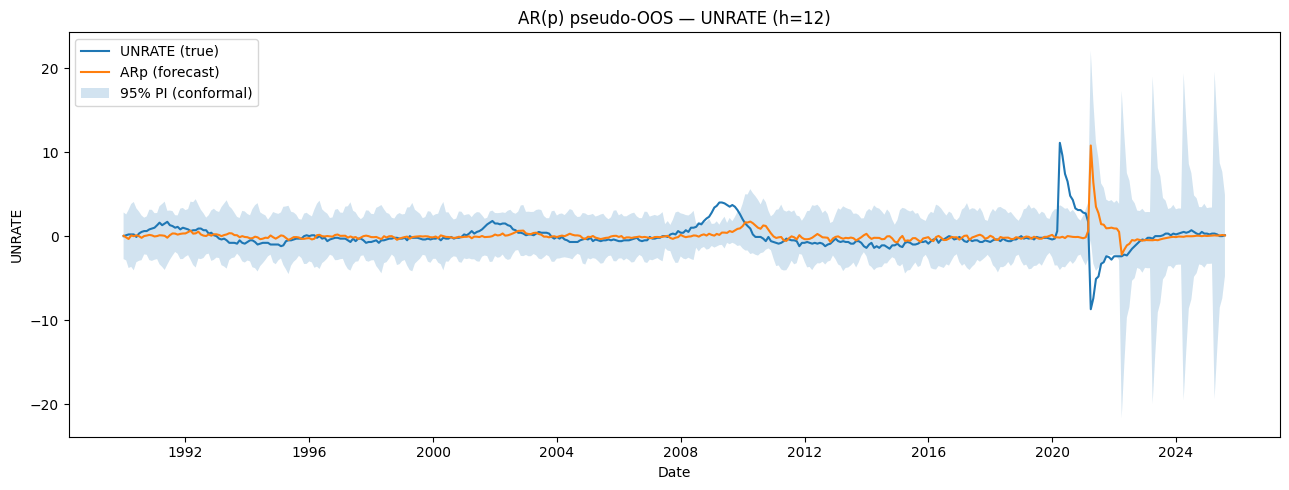

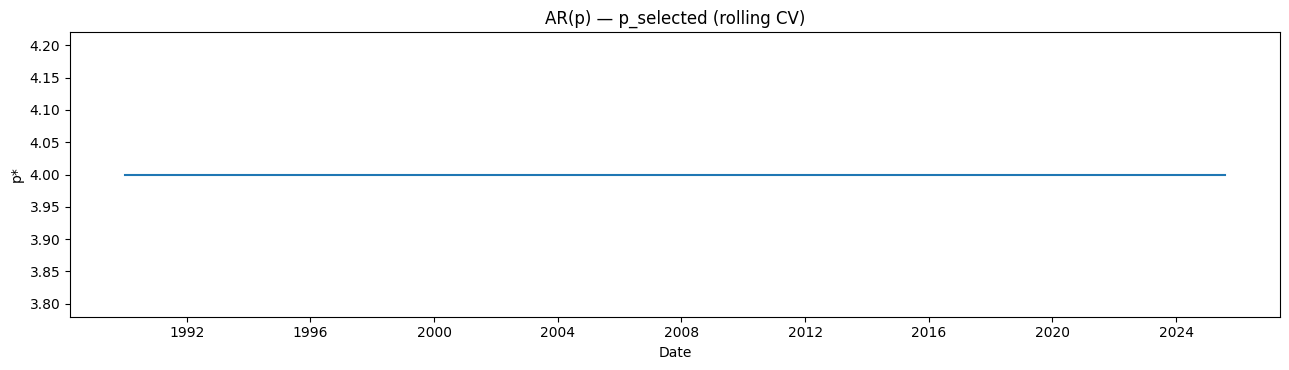

In [ ]:
# =========================================================
# Plot ARp (df_oos_ar_cv) : y_true vs y_hat + PI95 + p_selected
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "df_oos_ar_cv" in globals(), "df_oos_ar_cv is missing"

plot_df = df_oos_ar_cv.copy()
plot_df["ds"] = pd.to_datetime(plot_df["ds"], errors="coerce")
plot_df = plot_df.dropna(subset=["ds"]).sort_values("ds").reset_index(drop=True)

# safety: lower <= upper
if "lo_95" in plot_df.columns and "hi_95" in plot_df.columns:
    arr = plot_df[["lo_95", "hi_95"]].to_numpy(dtype=float)
    arr = np.sort(arr, axis=1)
    plot_df["lo_95"] = arr[:, 0]
    plot_df["hi_95"] = arr[:, 1]

# ---------- Plot 1: y_true vs y_hat + PI ----------
plt.figure(figsize=(13, 5))
plt.plot(plot_df["ds"], plot_df["y_true"].astype(float), label="UNRATE (true)")
plt.plot(plot_df["ds"], plot_df["y_hat"].astype(float), label="ARp (forecast)")

has_pi = plot_df["lo_95"].notna() & plot_df["hi_95"].notna()
if has_pi.any():
    plt.fill_between(
        plot_df.loc[has_pi, "ds"],
        plot_df.loc[has_pi, "lo_95"].astype(float),
        plot_df.loc[has_pi, "hi_95"].astype(float),
        alpha=0.2,
        label="95% PI (conformal)"
    )

plt.title("AR(p) pseudo-OOS — UNRATE (h=12)")
plt.xlabel("Date")
plt.ylabel("UNRATE")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- Plot 2: p_selected over time ----------
if "p_selected" in plot_df.columns:
    plt.figure(figsize=(13, 3.8))
    plt.plot(plot_df["ds"], pd.to_numeric(plot_df["p_selected"], errors="coerce"))
    plt.title("AR(p) — p_selected (rolling CV)")
    plt.xlabel("Date")
    plt.ylabel("p*")
    plt.tight_layout()
    plt.show()
    